In [7]:
import os
import gzip
import json
import pandas as pd

In [8]:
PATH = "./data/sports"

## Giải nén

In [3]:
dir_name_gz = "reviews_Sports_and_Outdoors_5.json.gz"
input_filepath_gz = os.path.join(PATH, dir_name_gz)

dir_name_json = dir_name_gz.replace(".json.gz", ".json")
output_filepath_json = os.path.join(PATH, dir_name_json)

with gzip.open(input_filepath_gz, 'rb') as f_in:
    with open(output_filepath_json, 'wb') as f_out:
        f_out.write(f_in.read())

print(f"Successfully unzipped {dir_name_gz} to {dir_name_json}")

Successfully unzipped reviews_Sports_and_Outdoors_5.json.gz to reviews_Sports_and_Outdoors_5.json


In [4]:
input_file = os.path.join(PATH, dir_name_json) # File nháy đơn
output_filepath_jsonl = os.path.join(PATH, dir_name_json.replace(".json", ".jsonl")) # File chuẩn

In [ ]:
# print("Đang chuẩn hóa dữ liệu...")

# with open(input_file, 'r', encoding='utf-8') as f_in, \
#      open(output_filepath_jsonl, 'w', encoding='utf-8') as f_out:
    
#     for line in f_in:
#         # 1. Dùng eval để đọc định dạng nháy đơn của Amazon
#         data_dict = eval(line)
        
#         # 2. Ghi lại bằng json.dumps để ép về chuẩn nháy kép
#         f_out.write(json.dumps(data_dict) + '\n')

# print(f"Hoàn thành! File chuẩn đã được lưu tại: {output_filepath_jsonl}")

In [5]:
import ast
import os

def fast_normalize(input_path, output_path, chunk_size=1000):
    print(f"Bắt đầu chuẩn hóa: {input_path}")
    
    with open(input_path, 'r', encoding='utf-8') as f_in, \
         open(output_path, 'w', encoding='utf-8') as f_out:
        
        buffer = []
        for line in f_in:
            line = line.strip()
            if not line: continue
            
            try:
                # ast.literal_eval nhanh và chuẩn hơn eval cho bài toán này
                data_dict = ast.literal_eval(line)
                buffer.append(json.dumps(data_dict) + '\n')
                
                # Khi đủ 1000 dòng thì ghi xuống ổ cứng 1 lần
                if len(buffer) >= chunk_size:
                    f_out.writelines(buffer)
                    buffer = []
            except:
                continue
        
        # Ghi nốt phần còn lại trong buffer
        if buffer:
            f_out.writelines(buffer)

    print(f"Hoàn thành! Đã lưu tại: {output_path}")
    print(f"Kích thước file mới: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

In [6]:
# Chạy thử
# fast_normalize(input_file, output_filepath_jsonl)

Bắt đầu chuẩn hóa: ./data/sports\reviews_Sports_and_Outdoors_5.json
Hoàn thành! Đã lưu tại: ./data/sports\reviews_Sports_and_Outdoors_5.jsonl
Kích thước file mới: 198.72 MB


In [7]:
with open(output_filepath_jsonl, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i < 5:  # Print the first 5 lines
            print(line.strip())
        else:
            break

{"reviewerID": "AIXZKN4ACSKI", "asin": "1881509818", "reviewerName": "David Briner", "helpful": [0, 0], "reviewText": "This came in on time and I am veru happy with it, I haved used it already and it makes taking out the pins in my glock 32 very easy", "overall": 5.0, "summary": "Woks very good", "unixReviewTime": 1390694400, "reviewTime": "01 26, 2014"}
{"reviewerID": "A1L5P841VIO02V", "asin": "1881509818", "reviewerName": "Jason A. Kramer", "helpful": [1, 1], "reviewText": "I had a factory Glock tool that I was using for my Glock 26, 27, and 17.  I've since lost it and had needed another.  Since I've used Ghost products prior, and know that they are reliable, I had decided to order this one.  Sure enough, this is just as good as a factory tool.", "overall": 5.0, "summary": "Works as well as the factory tool", "unixReviewTime": 1328140800, "reviewTime": "02 2, 2012"}
{"reviewerID": "AB2W04NI4OEAD", "asin": "1881509818", "reviewerName": "J. Fernald", "helpful": [2, 2], "reviewText": "I

In [59]:
with open(output_filepath_jsonl, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        data = json.loads(line) # Đọc từng dòng
        print(f"Dòng {i+1}: Sản phẩm: {data.get('asin', 'N/A')}, Tiêu đề: {data.get('title', 'N/A')}, Hình ảnh: {data.get('imUrl', 'N/A')}")
        if i == 4: # Chỉ xem thử 5 dòng đầu
            break

Dòng 1: Sản phẩm: 0000032069, Tiêu đề: Adult Ballet Tutu Cheetah Pink, Hình ảnh: http://ecx.images-amazon.com/images/I/51EzU6quNML._SX342_.jpg
Dòng 2: Sản phẩm: 0000031909, Tiêu đề: Girls Ballet Tutu Neon Pink, Hình ảnh: http://ecx.images-amazon.com/images/I/41xBoP0FVzL._SY300_.jpg
Dòng 3: Sản phẩm: 0000032034, Tiêu đề: Adult Ballet Tutu Yellow, Hình ảnh: http://ecx.images-amazon.com/images/I/21GNUNIa1CL.jpg
Dòng 4: Sản phẩm: 0000031852, Tiêu đề: Girls Ballet Tutu Zebra Hot Pink, Hình ảnh: http://ecx.images-amazon.com/images/I/51fAmVkTbyL._SY300_.jpg
Dòng 5: Sản phẩm: 0000032050, Tiêu đề: Adult Ballet Tutu Purple, Hình ảnh: http://ecx.images-amazon.com/images/I/41TxNYG8cwL._SX342_.jpg


In [ ]:
# dành cho file lớn, ở đây file nhỏ nên đọc trực tiếp
# chunks = pd.read_json(os.path.join(PATH, "reviews_Sports_and_Outdoors_5.jsonl"), lines=True, chunksize=100_000)
# df = next(chunks)
# chunks.close()

In [60]:
df = pd.read_json(output_filepath_jsonl, lines=True)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 532197 entries, 0 to 532196
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         532197 non-null  str    
 1   title        529901 non-null  str    
 2   price        287792 non-null  float64
 3   imUrl        531613 non-null  str    
 4   related      388118 non-null  object 
 5   brand        152487 non-null  str    
 6   categories   532197 non-null  object 
 7   salesRank    486349 non-null  object 
 8   description  402371 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 36.5+ MB


In [63]:
df.head(3)

,asin,title,price,imUrl,related,brand,categories,salesRank,description
0,0000032069,Adult Ballet Tutu Cheetah Pink,7.89,http://ecx.images-amazon.com/images/I/51EzU6qu...,"{'also_bought': ['0000032050', 'B00D0DJAEG', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN
1,0000031909,Girls Ballet Tutu Neon Pink,7.00,http://ecx.images-amazon.com/images/I/41xBoP0F...,"{'also_bought': ['B002BZX8Z6', 'B00JHONN1S', '...",Unknown,"[[Sports & Outdoors, Other Sports, Dance]]",{'Toys & Games': 201847},High quality 3 layer ballet tutu. 12 inches in...
2,0000032034,Adult Ballet Tutu Yellow,7.87,http://ecx.images-amazon.com/images/I/21GNUNIa...,"{'also_bought': ['B00D2JSRFQ', '0000032042', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN


## Load df

In [4]:
df_meta = pd.read_json(os.path.join(PATH, "meta_Sports_and_Outdoors.jsonl"), lines=True)

In [5]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 532197 entries, 0 to 532196
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         532197 non-null  str    
 1   title        529901 non-null  str    
 2   price        287792 non-null  float64
 3   imUrl        531613 non-null  str    
 4   related      388118 non-null  object 
 5   brand        152487 non-null  str    
 6   categories   532197 non-null  object 
 7   salesRank    486349 non-null  object 
 8   description  402371 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 269.6+ MB


In [6]:
# Loại bỏ các sản phẩm không có hình ảnh (vì SMORE là đa phương thức)
df_meta_clean = df_meta.dropna(subset=['imUrl']).copy()

In [7]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 532197 entries, 0 to 532196
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         532197 non-null  str    
 1   title        529901 non-null  str    
 2   price        287792 non-null  float64
 3   imUrl        531613 non-null  str    
 4   related      388118 non-null  object 
 5   brand        152487 non-null  str    
 6   categories   532197 non-null  object 
 7   salesRank    486349 non-null  object 
 8   description  402371 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 269.6+ MB


In [8]:
df_meta.head(3)

,asin,title,price,imUrl,related,brand,categories,salesRank,description
0,0000032069,Adult Ballet Tutu Cheetah Pink,7.89,http://ecx.images-amazon.com/images/I/51EzU6qu...,"{'also_bought': ['0000032050', 'B00D0DJAEG', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN
1,0000031909,Girls Ballet Tutu Neon Pink,7.00,http://ecx.images-amazon.com/images/I/41xBoP0F...,"{'also_bought': ['B002BZX8Z6', 'B00JHONN1S', '...",Unknown,"[[Sports & Outdoors, Other Sports, Dance]]",{'Toys & Games': 201847},High quality 3 layer ballet tutu. 12 inches in...
2,0000032034,Adult Ballet Tutu Yellow,7.87,http://ecx.images-amazon.com/images/I/21GNUNIa...,"{'also_bought': ['B00D2JSRFQ', '0000032042', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN


In [9]:
df_reviews = pd.read_json(os.path.join(PATH, "reviews_Sports_and_Outdoors_5.jsonl"), lines=True)

In [10]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 296337 entries, 0 to 296336
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   reviewerID      296337 non-null  str   
 1   asin            296337 non-null  str   
 2   reviewerName    294935 non-null  str   
 3   helpful         296337 non-null  object
 4   reviewText      296337 non-null  str   
 5   overall         296337 non-null  int64 
 6   summary         296337 non-null  str   
 7   unixReviewTime  296337 non-null  int64 
 8   reviewTime      296337 non-null  str   
dtypes: int64(2), object(1), str(6)
memory usage: 171.5+ MB


In [11]:
df_reviews.head(3)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AIXZKN4ACSKI,1881509818,David Briner,"[0, 0]",This came in on time and I am veru happy with ...,5,Woks very good,1390694400,"01 26, 2014"
1,A1L5P841VIO02V,1881509818,Jason A. Kramer,"[1, 1]",I had a factory Glock tool that I was using fo...,5,Works as well as the factory tool,1328140800,"02 2, 2012"
2,AB2W04NI4OEAD,1881509818,J. Fernald,"[2, 2]",If you don't have a 3/32 punch or would like t...,4,"It's a punch, that's all.",1330387200,"02 28, 2012"


In [12]:
# Lọc ra meta của sản phẩm có trong reviews 5 core
asins_in_reviews = set(df_reviews['asin'].unique())
df_meta_filtered = df_meta[df_meta['asin'].isin(asins_in_reviews)].copy()

In [13]:
df_meta_filtered.info()

<class 'pandas.DataFrame'>
Index: 18357 entries, 132 to 532165
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         18357 non-null  str    
 1   title        18267 non-null  str    
 2   price        14764 non-null  float64
 3   imUrl        18325 non-null  str    
 4   related      18236 non-null  object 
 5   brand        12333 non-null  str    
 6   categories   18357 non-null  object 
 7   salesRank    16055 non-null  object 
 8   description  16620 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 13.0+ MB


In [14]:
print(df_meta_filtered.shape)
print(df_reviews.shape)

(18357, 9)
(296337, 9)


In [15]:
df_meta_with_reviews = df_meta_filtered.merge(df_reviews, on='asin', how='inner')

In [16]:
df_meta_with_reviews.shape

(296337, 17)

In [17]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# df_meta_with_reviews.to_json(os.path.join(PATH, "meta_reviews_merged.jsonl"), orient='records', lines=True)
# write to parquet for faster loading in the future
df_meta_with_reviews.to_parquet(
    os.path.join(PATH, "meta_reviews_merged.gzip.parquet"), 
    engine='pyarrow', 
    compression='gzip', 
    index=False
)

In [33]:
df_ratings = pd.read_csv(r"data\sports\ratings_Sports_and_Outdoors.csv", names=['userID', 'itemID', 'rating', 'timestamp'], header=None)

In [34]:
df_ratings.shape

(3268695, 4)

In [38]:
df_ratings.head(3)

,userID,itemID,rating,timestamp
0,A3PMSRCL80KSA1,0000031852,4.0,1388275200
1,A1SNLWGLFXD70K,0000031852,4.0,1392940800
2,A1KJ4CVG87QW09,0000031852,4.0,1389657600


In [35]:
df_reviews.shape

(296337, 9)

In [40]:
asins_in_ratings = set(df_ratings['itemID'].unique())
df_meta_ratings_filtered = df_meta_filtered[df_meta_filtered['asin'].isin(asins_in_ratings)].copy()

In [41]:
df_meta_ratings_filtered.info()

<class 'pandas.DataFrame'>
Index: 18357 entries, 132 to 532165
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         18357 non-null  str    
 1   title        18267 non-null  str    
 2   price        14764 non-null  float64
 3   imUrl        18325 non-null  str    
 4   related      18236 non-null  object 
 5   brand        12333 non-null  str    
 6   categories   18357 non-null  object 
 7   salesRank    16055 non-null  object 
 8   description  16620 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 13.0+ MB


In [42]:
df_meta_ratings_filtered.shape

(18357, 9)

In [43]:
df_meta_filtered.shape

(18357, 9)

In [ ]:
# 2 vậy ratings và reviews 5 core khác size vì tiêu chỉ lọc khác nhau
# nhưng số sản phẩm liên quan vẫn y hệt
df_meta_ratings_filtered.compare(df_meta_filtered)

Empty DataFrame
Columns: []
Index: []

In [3]:
df_meta_filtered = pd.read_parquet(os.path.join(PATH, "meta_filtered.gzip.parquet"))

In [4]:
df_meta_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 18357 entries, 0 to 18356
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         18357 non-null  str    
 1   title        18267 non-null  str    
 2   price        14764 non-null  float64
 3   imUrl        18325 non-null  str    
 4   related      18236 non-null  object 
 5   brand        12333 non-null  str    
 6   categories   18357 non-null  object 
 7   salesRank    16055 non-null  object 
 8   description  16620 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 12.8+ MB


In [ ]:
# import array

# # https://cseweb.ucsd.edu/~jmcauley/datasets/amazon/links.html
# def readImageFeatures(path):
#   f = open(path, 'rb')
#   while True:
#     asin = f.read(10).decode('UTF-8')
#     if asin == '': break
#     a = array.array('f')
#     a.fromfile(f, 4096)
#     yield asin, a.tolist()

In [8]:
import numpy as np
import os

def extract_and_filter_features(path_b, valid_asin_set):
    """
    Đọc file .b, lọc các ASIN có trong valid_asin_set và trả về ma trận numpy.
    
    Args:
        path_b (str): Đường dẫn đến file image_features_Sports_and_Outdoors.b
        valid_asin_set (set): Tập hợp (set) các ASIN cần giữ lại (lấy từ df_meta_filtered['asin'])
        
    Returns:
        tuple: (Ma trận đặc trưng numpy float32, Danh sách ASIN tương ứng)
    """
    filtered_asins = []
    filtered_features = []
    
    # Kích thước phần vector: 4096 số float32 * 4 bytes = 16384 bytes
    feat_size_bytes = 4096 * 4 
    
    print(f"Bắt đầu trích xuất từ: {path_b}...")
    
    with open(path_b, 'rb') as f:
        while True:
            # 1. Đọc 10 bytes đầu tiên chứa ASIN
            asin_bytes = f.read(10)
            if not asin_bytes:
                break # Hết file
                
            asin = asin_bytes.decode('utf-8').strip()
            
            # 2. Kiểm tra nhanh trong SET (tốc độ O(1))
            if asin in valid_asin_set:
                # Nếu khớp, nạp vector vào RAM
                feat = np.fromfile(f, dtype='float32', count=4096)
                filtered_asins.append(asin)
                filtered_features.append(feat)
            else:
                # Nếu không khớp, nhảy qua vùng dữ liệu này (không tốn RAM để nạp)
                f.seek(feat_size_bytes, 1)
                
    # Chuyển list các vector thành ma trận 2D
    feature_matrix = np.array(filtered_features, dtype='float32')
    
    print(f"Xong! Giữ lại được {len(filtered_asins)} / {len(valid_asin_set)} sản phẩm.")
    return feature_matrix, filtered_asins

In [9]:
# --- CÁCH SỬ DỤNG ---
# 1. Tạo set ASIN để lookup nhanh
target_asins = set(df_meta_filtered['asin'].unique())

# 2. Chạy hàm
path_bin = os.path.join(PATH, "image_features_Sports_and_Outdoors.b")
image_matrix, image_asin_list = extract_and_filter_features(path_bin, target_asins)

# 3. Lưu lại để dùng cho huấn luyện
np.save(os.path.join(PATH, 'image_feat_final.npy'), image_matrix)

Bắt đầu trích xuất từ: ./data/sports\image_features_Sports_and_Outdoors.b...
Xong! Giữ lại được 18177 / 18357 sản phẩm.


In [14]:
# 2. Tạo một DataFrame mapping từ kết quả trả về
df_image_map = pd.DataFrame({
    'asin': image_asin_list,
    'image_index': range(len(image_asin_list))
})

In [34]:
# 1. Tạo một DataFrame tạm để giữ đúng thứ tự của Ảnh
df_image_order = pd.DataFrame({
    'asin': image_asin_list,
    'image_row_index': range(len(image_asin_list))
})

# 2. Merge với Metadata của bạn
# Phải dùng 'inner' join để loại bỏ những cái không có ảnh hoặc không có metadata
df_meta_with_image = pd.merge(df_image_order, df_meta_filtered, on='asin', how='inner')

# 3. Sắp xếp lại df_meta_final theo đúng thứ tự image_row_index
df_meta_with_image = df_meta_with_image.sort_values('image_row_index').reset_index(drop=True)

In [37]:
image_asin_list[:3]

['B000FON3KU', 'B000BSWEF0', 'B000ENOPO0']

In [38]:
df_meta_with_image.head(3)

,asin,image_row_index,title,price,imUrl,related,brand,categories,salesRank,description
0,B000FON3KU,0,Bionic Men's Fitness Gloves,NaN,http://ecx.images-amazon.com/images/I/4176MJfl...,"{'also_bought': ['B001ZTU4SS', 'B00H1KKLI8', '...",NaN,"[[Sports & Outdoors, Clothing, Men, Accessorie...","{'Arts, Crafts & Sewing': None, 'Automotive': ...",The men's fitness gloves from Bionic are desig...
1,B000BSWEF0,1,Spyderco C88PBK Salt I Lockback Knife,67.78,http://ecx.images-amazon.com/images/I/210Y76MV...,"{'also_bought': ['B004HIZKHE', 'B0018RMB8I', '...",Spyderco,"[[Sports & Outdoors, Hunting & Fishing, Huntin...","{'Arts, Crafts & Sewing': None, 'Automotive': ...",The Salt I has a more rounded tip that's a bit...
2,B000ENOPO0,2,Slime Tube Sealant,NaN,http://ecx.images-amazon.com/images/I/41GNiVJa...,"{'also_bought': ['B0020T17J2', 'B007OX6E3S', '...",NaN,"[[Sports & Outdoors, Cycling, Tires & Tubes, T...",None,Permanently seals tube punctures up to 1/8 inc...


In [11]:
df_meta_with_image["title"]

0                              Bionic Men's Fitness Gloves
1                    Spyderco C88PBK Salt I Lockback Knife
2                                       Slime Tube Sealant
3        DuPont Teflon Multi-Use Lubricant Aerosol Spra...
4                                            MSR Titan Cup
                               ...                        
18172     VZ Grips Operator II Standard Full Size Gun Grip
18173                   Igloo Stainless Steel Cooler Latch
18174    Ultimate Arms Gear Tactical Stealth Black M16 ...
18175                         Cressi Supernova Dry Snorkel
18176           UTG Swivel Stud Picatinny Slot Adaptor Kit
Name: title, Length: 18177, dtype: str

In [40]:
df_meta_with_image.to_parquet(os.path.join(PATH, "meta_with_image.gzip.parquet"), engine='pyarrow', compression='gzip', index=False)

In [41]:
image_matrix[0]

array([0.    , 0.    , 1.4426, ..., 0.    , 0.    , 0.    ],
      shape=(4096,), dtype=float32)

In [17]:
# target_asins


In [18]:
df_meta_filtered["asin"][:3]

0    1881509818
1    2094869245
2    7245456313
Name: asin, dtype: str

In [19]:
image_asin_list[:3]

['B000FON3KU', 'B000BSWEF0', 'B000ENOPO0']

In [22]:
df_meta_filtered[df_meta_filtered["asin"] == "B000FON3KU"]["asin"]

2343    B000FON3KU
Name: asin, dtype: str

In [9]:
df_meta_with_image = pd.read_parquet(os.path.join(PATH, "meta_with_image.gzip.parquet"))

In [1]:
import torch
print(torch.__version__)

2.10.0+cpu


In [4]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


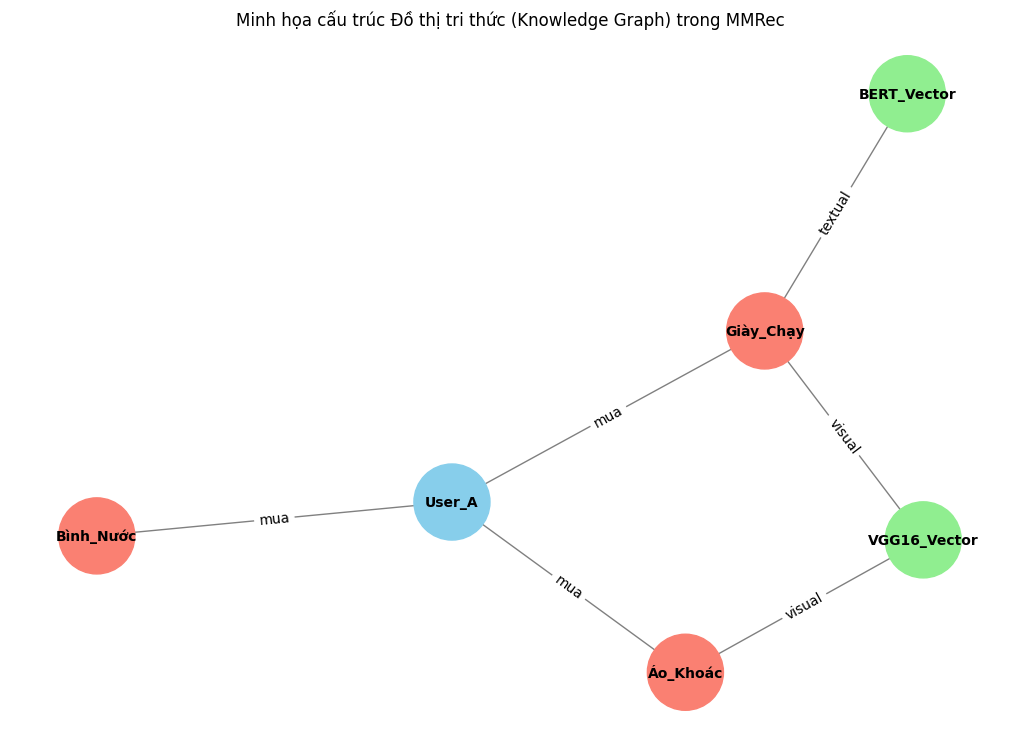

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Khởi tạo đồ thị
G = nx.Graph()

# 2. Thêm các Nút (Nodes) và phân loại nhóm để tô màu
user_node = "User_A"
items = ["Giày_Chạy", "Áo_Khoác", "Bình_Nước"]
features = ["VGG16_Vector", "BERT_Vector"]

G.add_node(user_node, type='user')
G.add_nodes_from(items, type='item')
G.add_nodes_from(features, type='feature')

# 3. Thêm các Cạnh (Edges) - Thiết lập mối quan hệ
# User mua sản phẩm
for item in items:
    G.add_edge(user_node, item, label='mua')

# Sản phẩm có đặc trưng đa phương thức
G.add_edge("Giày_Chạy", "VGG16_Vector", label='visual')
G.add_edge("Giày_Chạy", "BERT_Vector", label='textual')
G.add_edge("Áo_Khoác", "VGG16_Vector", label='visual')

# 4. Thiết lập vị trí và màu sắc để vẽ cho đẹp
pos = nx.spring_layout(G, seed=42) # Sắp xếp nút tự động

# Tô màu: User (Xanh dương), Item (Đỏ), Feature (Xanh lá)
color_map = []
for node in G:
    if G.nodes[node]['type'] == 'user':
        color_map.append('skyblue')
    elif G.nodes[node]['type'] == 'item':
        color_map.append('salmon')
    else:
        color_map.append('lightgreen')

# 5. Vẽ đồ thị
plt.figure(figsize=(10, 7))
nx.draw(G, pos, with_labels=True, node_color=color_map, 
        node_size=3000, font_size=10, font_weight='bold', edge_color='gray')

# Vẽ nhãn cho các cạnh (mua, visual, textual)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Minh họa cấu trúc Đồ thị tri thức (Knowledge Graph) trong MMRec")
plt.show()

In [ ]:
import dgl
import torch
import pandas as pd

# 1. Tạo mapping cho User và Item (Vì SMORE cần ID dạng số)
user_ids = df['reviewerID'].astype('category').cat.codes.values
item_ids = df['asin'].astype('category').cat.codes.values

# 2. Khởi tạo đồ thị dị thể (Heterograph)
# Định nghĩa quan hệ: (loại_nút_nguồn, tên_quan_he, loại_nút_đích)
graph_data = {
   ('user', 'rates', 'item'): (torch.tensor(user_ids), torch.tensor(item_ids)),
   ('item', 'rated_by', 'user'): (torch.tensor(item_ids), torch.tensor(user_ids))
}
g = dgl.heterograph(graph_data)

# 3. Gán thuộc tính điểm số (overall) vào cạnh
g.edges['rates'].data['rating'] = torch.tensor(df['overall'].values, dtype=torch.float32)

print(g)